#Testing Graph Neural Networks for Spotify Song Recommendation

CSC 578

Zara Zarzour

rhammad1@depaul.edu

This project examines how Graph Neural Networks (GNNs) can be used to recommend Spotify songs by
analyzing musical features like genre, danceability, and energy. The goal is to evaluate the performance
of these models using metrics such as training and validation losses and ROC curves. In this project, we
test whether GNNs can effectively model relationships between songs for recommendation purposes while
achieving satisfactory performance. Although this study is inconclusive, key insights can be drawn from the
comparative analysis of the different architectures and metrics. Note that AI was utilized in multiple parts of this project.

In [ ]:
# connect to google drive so I can pull data from my drive
from google.colab import drive
drive.mount('/content/drive')

# change directories to my drive
%cd /content/drive/MyDrive/

Mounted at /content/drive
/content/drive/MyDrive


###Install and load libraries

In [ ]:
# install torch geometric
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.4 MB/s eta 0:00:00


Load all other necessary libraries

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from torch_geometric.nn import LGConv
from torch_geometric.nn import SAGEConv
from torch_geometric.nn import GATConv
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

###Load Data

The selected data is collected from Spotify and can be downloaded here: https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks?resource=download

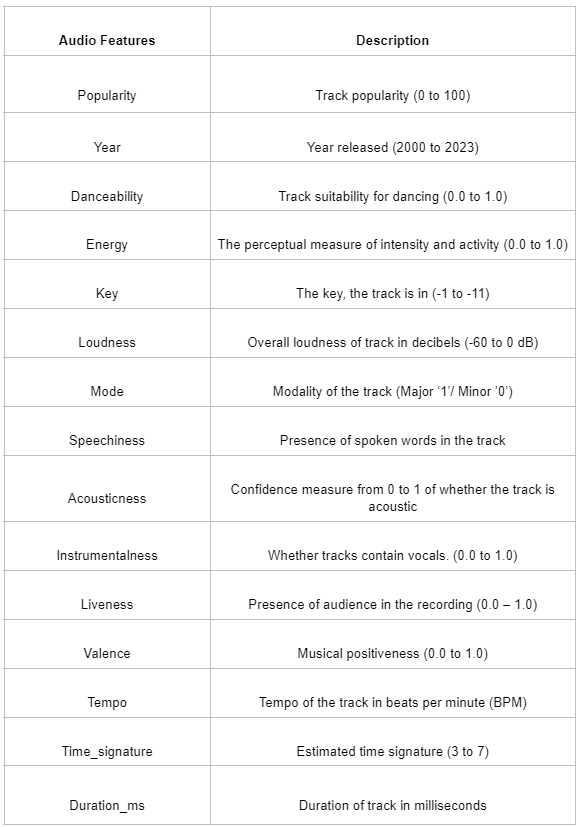

In [ ]:
# load and sample the dataset
spotify_data = pd.read_csv('spotify_data.csv')
sample_size = 50000  # lowering sample size for memory efficiency; using the full dataset leads to the code crashing
spotify_data = spotify_data.sample(n = sample_size, random_state = 42).reset_index(drop = True)

In [ ]:
# show the first few rows
print("First 5 rows of the dataset:")
print(spotify_data.head())

First 5 rows of the dataset:
   Unnamed: 0      artist_name                     track_name  \
0     1054304            Cabas             Amor De Mis Amores   
1      621408  Ketil Bjørnstad                    Første sang   
2     1121669       Project 86  Evil (A Chorus Of Resistance)   
3      439351         Ital Tek                     Open Heart   
4      266036            I-Roy                     Irie Right   

                 track_id  popularity  year      genre  danceability  energy  \
0  3FTqjWmL21xi4HTTOq94EQ          38  2006   alt-rock         0.725   0.553   
1  0Pt7ESPgrdTdaxp2f29hX2          11  2023    swedish         0.277   0.164   
2  75Ub3ckaoTdzgH9Azeu8cY          38  2007   alt-rock         0.486   0.927   
3  5WEPna9GWi0NkqVLAkEKNN          18  2020    dubstep         0.411   0.442   
4  6peHySxvmZaRF9YEwUsggq          18  2017  dancehall         0.748   0.660   

   key  loudness  mode  speechiness  acousticness  instrumentalness  liveness  \
0    6    -6.319  

In [ ]:
# show basic info about the dataset
print("\nDataset info:")
print(spotify_data.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        50000 non-null  int64  
 1   artist_name       50000 non-null  object 
 2   track_name        50000 non-null  object 
 3   track_id          50000 non-null  object 
 4   popularity        50000 non-null  int64  
 5   year              50000 non-null  int64  
 6   genre             50000 non-null  object 
 7   danceability      50000 non-null  float64
 8   energy            50000 non-null  float64
 9   key               50000 non-null  int64  
 10  loudness          50000 non-null  float64
 11  mode              50000 non-null  int64  
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           50000 n

In [ ]:
# check for missing values
print("\nMissing values:")
print(spotify_data.isnull().sum())


Missing values:
Unnamed: 0          0
artist_name         0
track_name          0
track_id            0
popularity          0
year                0
genre               0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
dtype: int64


There are no missing values in this dataset; proceed with processing data.

###Data Preprocessing

The features selected include danceability, energy, key, loudness, speechiness, acousticness, instrumentalness, liveness, valence, and tempo. These are the most relevant features based on the data dictionary/ intuition.

In [ ]:
# relevant features
features = spotify_data[['danceability', 'energy', 'key', 'loudness',
                         'speechiness', 'acousticness', 'instrumentalness',
                         'liveness', 'valence', 'tempo']].values

# normalize features
scaler = StandardScaler()
features = scaler.fit_transform(features)

# convert to tensor
features = torch.tensor(features, dtype = torch.float)

The preprocessing step below constructs a graph dataset for a GNN using k-NN to define the graph. The function generates an 'edge_index tensor' by calculating the k-nearest neighbors for each of the nodes based on their cosine similarity, or basically the similarities between songs. This setup is essential for implementing and evaluating more complex GNN architectures to follow.

In [ ]:
# function to create edge_index based on k-NN
def create_knn_edge_index(features, k = 10):
    # utilized AI to configure this setup
    nbrs = NearestNeighbors(n_neighbors = k, metric = 'cosine').fit(features.numpy())
    _, indices = nbrs.kneighbors(features.numpy())

    edge_index = []
    for i, neighbors in enumerate(indices):
        for j in neighbors:
            if i != j:
                edge_index.append([i, j])
                edge_index.append([j, i])
    return torch.tensor(edge_index, dtype = torch.long).t().contiguous()

# create edge_index using k-NN
edge_index = create_knn_edge_index(features, k = 10)
data = Data(x = features, edge_index = edge_index)

# add synthetic binary labels to data.y for demonstration purposes
num_nodes = features.shape[0]
data.y = torch.randint(0, 2, (num_nodes,), dtype = torch.long)  # random 0 or 1 labels

# train/ validation split
train_indices, val_indices = train_test_split(range(num_nodes), test_size = 0.2, random_state = 42)

The code chunk below performs clustering and evaluates its performance on the dataset using k-means and PCA. This step is ultimately for exploring the effectiveness of clustering and its potential alignment with the existing labels in my dataset.

In [ ]:
# dimensionality reduction with PCA to improve clustering
pca = PCA(n_components = 8)  # reduce dimensions to 8
features_reduced = pca.fit_transform(features)

# dplit data into train and validation sets
train_features, val_features, train_indices, val_indices = train_test_split(
    features_reduced, range(len(features_reduced)), test_size = 0.2, random_state = 42
)

# test different cluster counts
for num_clusters in [5, 10, 15, 20]:
    # define and fit the KMeans model
    kmeans = KMeans(n_clusters = num_clusters, random_state = 42)
    kmeans.fit(train_features)

    # predict clusters for both training and validation sets
    train_labels = kmeans.predict(train_features)
    val_labels = kmeans.predict(val_features)

    # calculate silhouette scores as a proxy for train and validation loss
    train_silhouette = silhouette_score(train_features, train_labels)
    val_silhouette = silhouette_score(val_features, val_labels)

    print(f"\nnumber of clusters: {num_clusters}")
    print(f"train silhouette score: {train_silhouette:.4f}")
    print(f"validation silhouette score: {val_silhouette:.4f}")


number of clusters: 5
train silhouette score: 0.1314
validation silhouette score: 0.1308

number of clusters: 10
train silhouette score: 0.1599
validation silhouette score: 0.1612

number of clusters: 15
train silhouette score: 0.1482
validation silhouette score: 0.1475

number of clusters: 20
train silhouette score: 0.1433
validation silhouette score: 0.1419


The highest silhouette score occurs with 10 clusters, suggesting this is likely the most effective number of clusters for this dataset among the options tested. However, all the silhouette scores are generally low (all close to 0), indicating that the clusters are not very well-defined.

##Testing GCNet, LGNet, SAGENet, and GATNet

In the code chunks below, I will be testing a few convulational layers that I learned about (mainly from this article): https://medium.com/stanford-cs224w/spotify-track-neural-recommender-system-51d266e31e16

This code below defines four GNN architectures (GCNet, LGNet, SAGENet, GATNet) and a training/ evaluation pipeline to compare their performances. Each network processes the graph data we created above with node features and edges, while employing different convolutional layers: A baseline GNN model, LGNet uses lightweight graph convolutions, SAGENet utilizes SAGEConv layers, and GATNet leverages attention-based graph convolutions. The training and evaluation function trains each model using cross-entropy loss and tracks their performances using training and validation losses and ROC scores. Finally, the models are trained and evaluated, with their results are stored for comparison.

In [ ]:
# utilized AI to configure this setup
class GCNet(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCNet, self).__init__()
        # first graph conv layer
        self.conv1 = GCNConv(input_dim, hidden_dim)
        # second graph conv layer
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # first graph conv and ReLU activation
        x = F.relu(self.conv1(x, edge_index))
        # second grah conv
        x = self.conv2(x, edge_index)
        return x

In [ ]:
# utilized AI to configure this setup
class LGNet(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LGNet, self).__init__()
        # graph conv layers
        self.conv1 = LGConv()
        self.conv2 = LGConv()
        # fully connected layers for feature transformation
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # fully connected layer and ReLU activation
        x = F.relu(self.fc1(x))
        # first graph conv layer
        x = self.conv1(x, edge_index)
        # second graph conv layer and ReLU activation
        x = F.relu(self.conv2(x, edge_index))
        # output transformation
        x = self.fc2(x)
        return x

In [ ]:
# utilized AI to configure this setup
class SAGENet(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SAGENet, self).__init__()
        # SAGE conv laydrs
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, output_dim)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # first SAGE conv and ReLU activation
        x = F.relu(self.conv1(x, edge_index))
        # second SAGE conv
        x = self.conv2(x, edge_index)
        return x

In [ ]:
# utilized AI to configure this setup
class GATNet(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, heads = 2):
        super(GATNet, self).__init__()
        # girst GAT layer
        self.conv1 = GATConv(input_dim, hidden_dim, heads = heads, concat = True)
        # second GAT layer
        self.conv2 = GATConv(hidden_dim * heads, output_dim, heads = 1, concat = False)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # first GAT layer and ELU activation
        x = F.elu(self.conv1(x, edge_index))
        # second GAT layer
        x = self.conv2(x, edge_index)
        return x

##Training and Evaluation

In [ ]:
# training and evaluation Function
def train_and_evaluate(model, data, train_indices, val_indices, epochs = 100):

    # using adam optimizer with a learning rate of 0.001 and L2 regularization
    optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, weight_decay = 5e-4)
    history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'train_roc': [], 'val_roc': []}

    for epoch in range(epochs):
        # training
        model.train()
        optimizer.zero_grad()
        embeddings = model(data)

        # calculate training loss and ROC
        train_embeddings = embeddings[train_indices]
        train_labels = data.y[train_indices]
        train_loss = F.cross_entropy(train_embeddings, train_labels)
        train_loss.backward()
        optimizer.step()

        # training ROC (utilized AI to troubleshoot)
        train_roc = roc_auc_score(train_labels.numpy(), train_embeddings.detach().numpy()[:, 1])

        # validation
        model.eval()
        with torch.no_grad():
            val_embeddings = model(data)[val_indices]
            val_labels = data.y[val_indices]
            val_loss = F.cross_entropy(val_embeddings, val_labels)

            # validation ROC (utilized AI to troubleshoot)
            val_roc = roc_auc_score(val_labels.numpy(), val_embeddings.numpy()[:, 1])

        # store metrics
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss.item())
        history['val_loss'].append(val_loss.item())
        history['train_roc'].append(train_roc)
        history['val_roc'].append(val_roc)

        if epoch % 10 == 0:
            print(f"epoch {epoch}, train Loss: {train_loss.item()}, val Loss: {val_loss.item()}, train ROC: {train_roc:.4f}, val ROC: {val_roc:.4f}")

    return history

In [ ]:
# initiate models and evaluate each one
input_dim = features.shape[1]
hidden_dim = 32
embedding_dim = 16

GC_model = GCNet(input_dim, hidden_dim, embedding_dim)
lg_model = LGNet(input_dim, hidden_dim, embedding_dim)
sage_model = SAGENet(input_dim, hidden_dim, embedding_dim)
gat_model = GATNet(input_dim, hidden_dim, embedding_dim)

# run training and evaluation for each model
history_gc = train_and_evaluate(GC_model, data, train_indices, val_indices)
history_lg = train_and_evaluate(lg_model, data, train_indices, val_indices)
history_sage = train_and_evaluate(sage_model, data, train_indices, val_indices)
history_gat = train_and_evaluate(gat_model, data, train_indices, val_indices)

# store results for comparison
results = {
    "GCNConv": history_gc,
    "LGConv": history_lg,
    "SAGEConv": history_sage,
    "GATConv": history_gat
}

epoch 0, train Loss: 3.061814308166504, val Loss: 3.041790008544922, train ROC: 0.5014, val ROC: 0.4995
epoch 10, train Loss: 2.8332135677337646, val Loss: 2.8125863075256348, train ROC: 0.5011, val ROC: 0.4999
epoch 20, train Loss: 2.617769241333008, val Loss: 2.5965750217437744, train ROC: 0.5008, val ROC: 0.5006
epoch 30, train Loss: 2.4145004749298096, val Loss: 2.392829179763794, train ROC: 0.5005, val ROC: 0.5013
epoch 40, train Loss: 2.222745418548584, val Loss: 2.2007975578308105, train ROC: 0.5002, val ROC: 0.5020
epoch 50, train Loss: 2.04225754737854, val Loss: 2.0202646255493164, train ROC: 0.4998, val ROC: 0.5024
epoch 60, train Loss: 1.872970700263977, val Loss: 1.8511792421340942, train ROC: 0.4994, val ROC: 0.5027
epoch 70, train Loss: 1.7150872945785522, val Loss: 1.6937824487686157, train ROC: 0.4990, val ROC: 0.5028
epoch 80, train Loss: 1.5693628787994385, val Loss: 1.5489212274551392, train ROC: 0.4987, val ROC: 0.5030
epoch 90, train Loss: 1.4370640516281128, val 

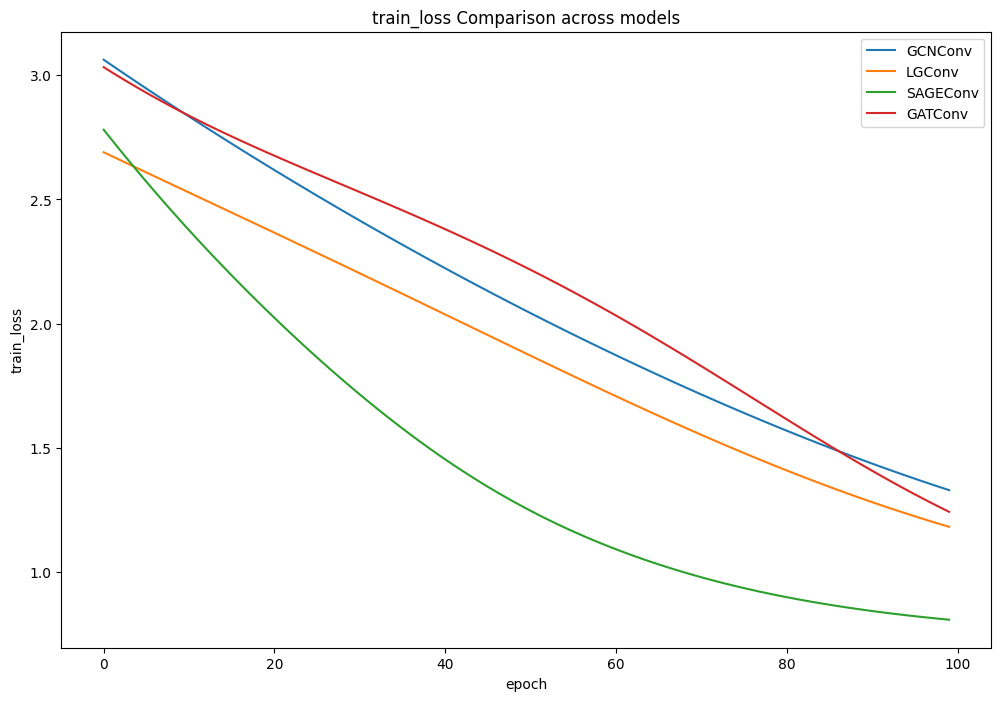

In [ ]:
# plotting function for comparison
def plot_results(results, metric):
    plt.figure(figsize = (12, 8))
    for model_name, history in results.items():
        plt.plot(history['epoch'], history[metric], label = model_name)
    plt.xlabel('epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.title(f'{metric} Comparison across models')
    plt.show()

plot_results(results, 'train_loss')

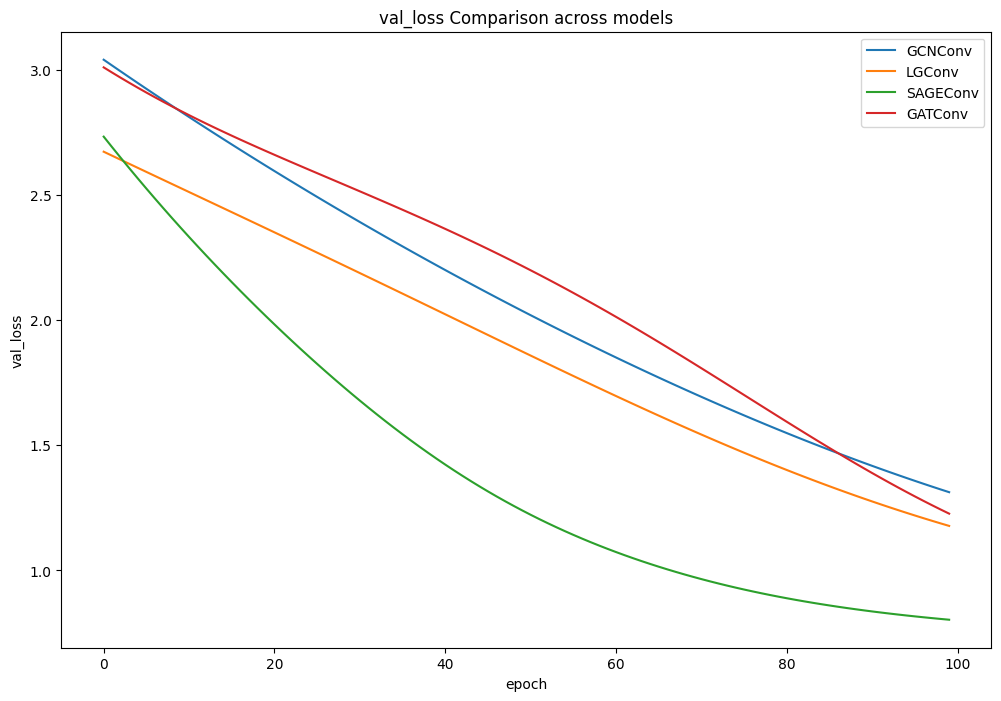

In [ ]:
plot_results(results, 'val_loss')

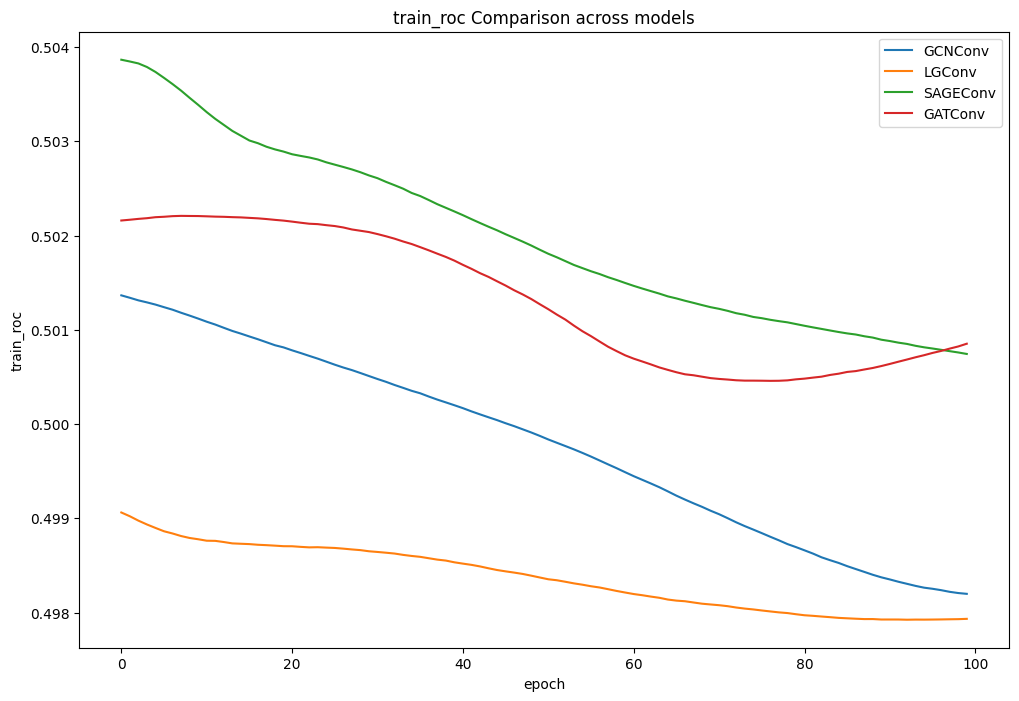

In [ ]:
plot_results(results, 'train_roc')

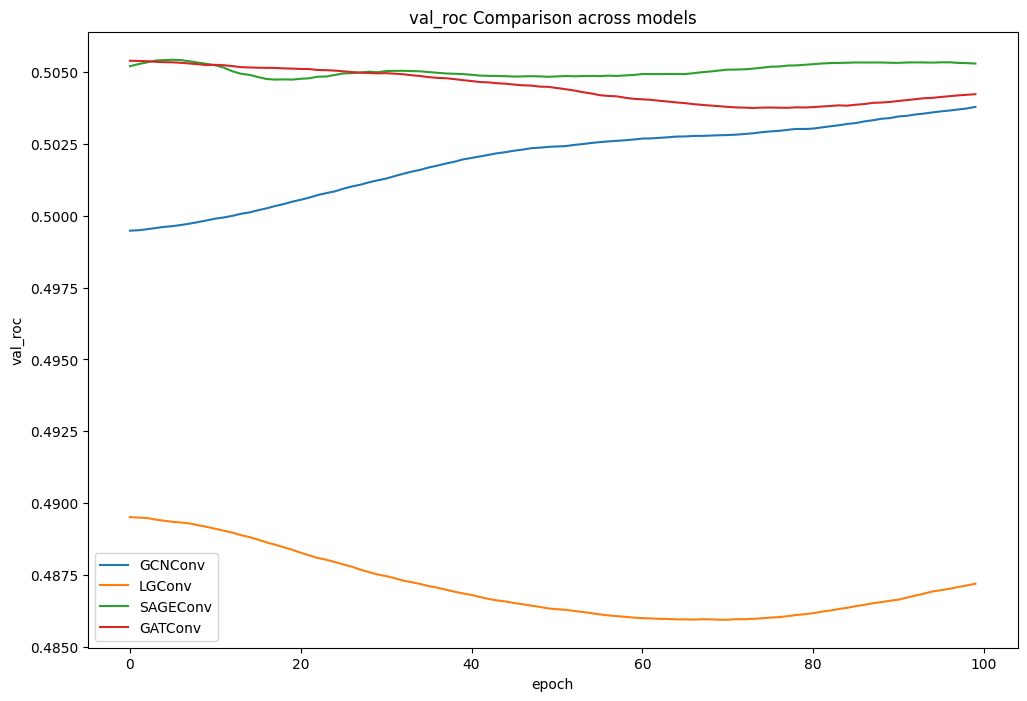

In [ ]:
plot_results(results, 'val_roc')

The SAGEConv performed the best out of the options above. With the help of AI, I've developed the enhanced version below which includes batch normalization for 'more stable training and faster convergence', residual connections for 'better gradient flow and feature retention', and a customizable dropout rate to reduce overfitting. These changes were suggested to improve the model's learning, robustness, and generalization to unseen data.

In [ ]:
# utilized AI to make the improvements to SAGEConv
class SAGENetEnhanced(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, embedding_dim, dropout_rate=0.3):
        super(SAGENetEnhanced, self).__init__()
        # SAGE conv layers
        self.conv1 = SAGEConv(input_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, embedding_dim)  # additional layer
        # batch normalization layers
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)
        self.dropout = torch.nn.Dropout(dropout_rate) # dropout layer

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # first SAGE conv with ReLU, batch norm, and dropout
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        # second SAGE conv with ReLU, batch norm, and dropout
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        # third SAGE conv (no activation for output layer)
        x = self.conv3(x, edge_index)
        return x

sage_model_enhanced = SAGENetEnhanced(input_dim, hidden_dim, embedding_dim, dropout_rate = 0.4)
history_sage_enhanced = train_and_evaluate(sage_model_enhanced, data, train_indices, val_indices)

epoch 0, train Loss: 2.7028613090515137, val Loss: 2.490499496459961, train ROC: 0.4993, val ROC: 0.4999
epoch 10, train Loss: 2.2330520153045654, val Loss: 2.3143701553344727, train ROC: 0.4985, val ROC: 0.5058
epoch 20, train Loss: 1.8399202823638916, val Loss: 2.001901388168335, train ROC: 0.5000, val ROC: 0.5063
epoch 30, train Loss: 1.527299165725708, val Loss: 1.647710919380188, train ROC: 0.4991, val ROC: 0.5050
epoch 40, train Loss: 1.2860885858535767, val Loss: 1.3390928506851196, train ROC: 0.5001, val ROC: 0.5058
epoch 50, train Loss: 1.1148598194122314, val Loss: 1.1399580240249634, train ROC: 0.5009, val ROC: 0.5063
epoch 60, train Loss: 0.9990532994270325, val Loss: 1.0209418535232544, train ROC: 0.5055, val ROC: 0.5054
epoch 70, train Loss: 0.9222528338432312, val Loss: 0.9410507082939148, train ROC: 0.5038, val ROC: 0.5038
epoch 80, train Loss: 0.8710547685623169, val Loss: 0.882714569568634, train ROC: 0.5055, val ROC: 0.5025
epoch 90, train Loss: 0.834389328956604, va

In [ ]:
# store results for comparison
results = {
    "SAGEConvEnhanced": history_sage_enhanced,
    "SAGEConv": history_sage
}

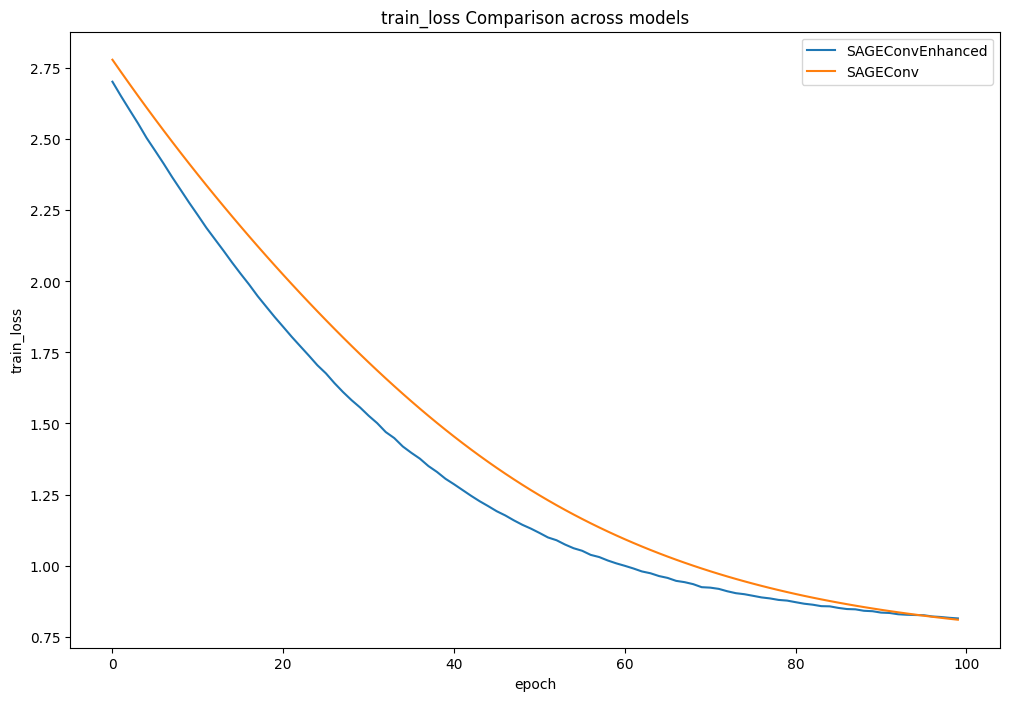

In [ ]:
plot_results(results, 'train_loss')

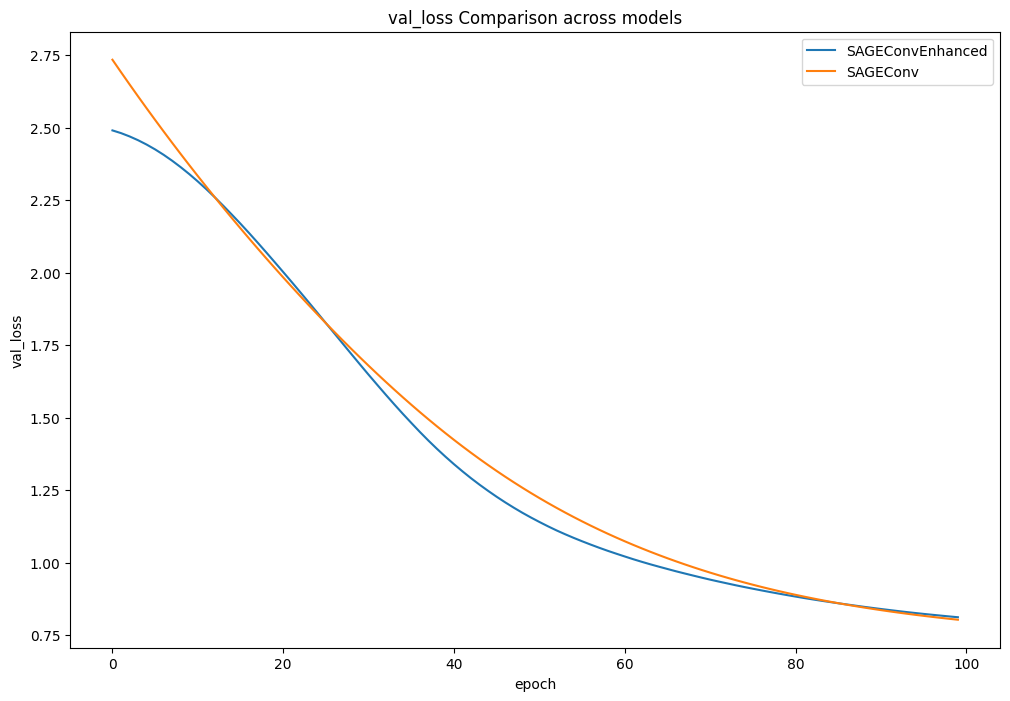

In [ ]:
plot_results(results, 'val_loss')

The results above show very minimal improvement in the enhanced SAGEConv model.

##Generate Recommendations

Build a function to generate recommendations:

In [ ]:
def generate_recommendations(model, data, spotify_data, song_index, top_k = 10):
    # set model to evaluation mode
    model.eval()
    with torch.no_grad():
        embeddings = model(data).cpu().numpy()

    # get the embedding of the selected song
    target_embedding = embeddings[song_index].reshape(1, -1)

    # calculate the cosine similarity with all other song embeddings
    similarities = cosine_similarity(target_embedding, embeddings)[0]

    # sort indices by similarity in descending order
    similar_indices = similarities.argsort()[::-1]
    similar_indices = [i for i in similar_indices if i != song_index][:top_k]

    # selected song information
    selected_song = spotify_data.iloc[song_index][['track_name', 'artist_name']]

    # recommended songs with similarity scores
    recommended_songs = spotify_data.iloc[similar_indices][['track_name', 'artist_name']].copy()
    recommended_songs['similarity'] = similarities[similar_indices]

    # display output
    print("Song selected:")
    print(selected_song.to_frame().T)

    print("\nTop 10 recommended songs:")
    print(recommended_songs.reset_index(drop = True))

# example usage
song_index = 0  # replace with the actual index of the song you want to find recommendations for
generate_recommendations(sage_model_enhanced, data, spotify_data, song_index, top_k = 10)

Song selected:
           track_name artist_name
0  Amor De Mis Amores       Cabas

Top 10 recommended songs:
                 track_name            artist_name  similarity
0         One Of These Days        Glen Washington    0.999705
1                 PATCHWERK              Sub Urban    0.999551
2          Bring It On Home             Tyree Neal    0.999475
3            West End Story            Dub Pistols    0.999444
4  Changes (Things In Life)             Don Carlos    0.999413
5      Let Your Light Shine               Keb' Mo'    0.999318
6       A Arpa e o Acordeao                  Josue    0.999309
7                 Filme moi           Alice et Moi    0.999277
8         Perreando - Remix               Don Omar    0.999257
9                   Soy Asi  Alameños de la Sierra    0.999254


In [ ]:
song_index = 85
generate_recommendations(sage_model_enhanced, data, spotify_data, song_index, top_k = 10)

Song selected:
              track_name artist_name
85  תפילה - 1985 Version   Ofra Haza

Top 10 recommended songs:
                                track_name                      artist_name  \
0                                    Jirim                 Orchestra Baobab   
1                   Ndiwe Wandaivimba Naye  John Chibadura & Tembo Brothers   
2                   逝去日子 - 無綫電視劇「淘氣雙子星」主題曲                           Beyond   
3                         Rudo Rwechokwadi                   Simon Chimbetu   
4                                 No No No              Those Poor Bastards   
5                           Snus-kig blues                     Eddie Meduza   
6  Cabelo Pixain / Deixa Clarear - Ao Vivo                   Caju Pra Baixo   
7                           Feel Like I Do                     Eric Lindell   
8    Cheza (feat. Joyce Ouko) - Percapella                      Bongoloverz   
9                Chega / Fui Dando Porrada                         Tradição   

   similarity 

In [ ]:
song_index = 1399
generate_recommendations(sage_model_enhanced, data, spotify_data, song_index, top_k = 10)

Song selected:
                             track_name          artist_name
1399  Moth To A Flame (with The Weeknd)  Swedish House Mafia

Top 10 recommended songs:
                                       track_name     artist_name  similarity
0                                            Unda            Faun    0.999831
1                          Will We Remain? - Edit  Ilan Bluestone    0.999808
2         One Night (feat. Raphaella) - 6am Remix              MK    0.999757
3                                       Buzzhenge   Circa Survive    0.999743
4                                   Price Of Love            Grum    0.999681
5                                       Invisible     Poisonblack    0.999649
6                                  Ending Is Love          Takida    0.999625
7                          I Can't Find The Words     K-Ci & JoJo    0.999622
8                                     Second Life           Klaas    0.999615
9  Colors (Xan Griffin Remix) [feat. Jackie Rain]       

In [ ]:
song_index = 2942
generate_recommendations(sage_model_enhanced, data, spotify_data , song_index, top_k = 10)

Song selected:
                    track_name    artist_name
2942  Bandaid On A Bullet Hole  Morgan Wallen

Top 10 recommended songs:
                   track_name        artist_name  similarity
0  Take Me Back To That Place        Mark Bishop    0.999892
1         Voice Of The Father       Crist Family    0.999867
2                        逆時車站          Kaho Hung    0.999853
3              Ele Sempre Vem    Canção & Louvor    0.999834
4                       如何忍眼淚        Sammi Cheng    0.999816
5                    Scorpios           Scorpios    0.999792
6            Shiv Stavan Path  Shounak Abhisheki    0.999791
7       Fica Só um Pouco Mais     Jorge & Mateus    0.999766
8                       戀愛最初回         Kenny Kwan    0.999753
9                 流水落花 - Live      劉卓軒 Hinry Lau    0.999752
